# Credit Risk Analysis

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Exploratory Data Analysis

In [107]:
loan_data = pd.read_csv("Task 3 and 4_Loan_Data.csv")

loan_data.head()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


In [108]:
# Data Analysis
print(loan_data.shape)
print("-" * 25)
print(loan_data.dtypes)
print("-" * 25)
print(loan_data.describe().loc[['min', 'max']])

(10000, 8)
-------------------------
customer_id                   int64
credit_lines_outstanding      int64
loan_amt_outstanding        float64
total_debt_outstanding      float64
income                      float64
years_employed                int64
fico_score                    int64
default                       int64
dtype: object
-------------------------
     customer_id  credit_lines_outstanding  loan_amt_outstanding  \
min    1000324.0                       0.0             46.783973   
max    8999789.0                       5.0          10750.677810   

     total_debt_outstanding       income  years_employed  fico_score  default  
min               31.652732    1000.0000             0.0       408.0      0.0  
max            43688.784100  148412.1805            10.0       850.0      1.0  


# Models

# 1. Logistic Regression

In [109]:
# y: default
# X: all other variables except customer_id

X = loan_data.drop(columns=["default", "customer_id"]).to_numpy()
y = loan_data["default"].to_numpy()

# Train/Val/Test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp)

# Standardize features
mean = X_train.mean(axis=0)
std  = X_train.std(axis=0)
X_train_s = (X_train - mean) / std
X_val_s   = (X_val   - mean) / std
X_test_s  = (X_test  - mean) / std

# Add intercept term
X_train_s = np.column_stack([np.ones(X_train_s.shape[0]), X_train_s])
X_val_s   = np.column_stack([np.ones(X_val_s.shape[0]),   X_val_s])
X_test_s  = np.column_stack([np.ones(X_test_s.shape[0]),  X_test_s])

# Step 1: Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Step 2: Loss function
def cross_entropy_loss(y_true, p_pred):
    epsilon = 1e-15  
    p_pred = np.clip(p_pred, epsilon, 1 - epsilon) # to restrict value between epsilon and 1 - epsilon
    loss = -np.mean(y_true * np.log(p_pred) + (1 - y_true) * np.log(1 - p_pred))
    return loss

# Step 3: Gradient descent + Training loop
def train_loop(X_train, y_train, X_val, y_val, beta, learning_rate=0.01, max_iter=1000):
    train_loss = []
    val_loss = []

    for i in range(max_iter):
        z = X_train @ beta
        p_pred = sigmoid(z)
        gradient = X_train.T @ (p_pred - y_train) / len(y_train)
        beta -= learning_rate * gradient

        train_loss.append(cross_entropy_loss(y_train, sigmoid(X_train @ beta)))
        val_loss.append(cross_entropy_loss(y_val, sigmoid(X_val @ beta)))

        if i % 100 == 0:
            print(f"iter {i}: train_loss = {train_loss[-1]:.4f}, val_loss = {val_loss[-1]:.4f}")

    return beta, train_loss, val_loss

iter 0: train_loss = 0.6610, val_loss = 0.6608
iter 100: train_loss = 0.1491, val_loss = 0.1487
iter 200: train_loss = 0.1028, val_loss = 0.1027
iter 300: train_loss = 0.0843, val_loss = 0.0842
iter 400: train_loss = 0.0739, val_loss = 0.0738
iter 500: train_loss = 0.0671, val_loss = 0.0670
iter 600: train_loss = 0.0623, val_loss = 0.0622
iter 700: train_loss = 0.0586, val_loss = 0.0585
iter 800: train_loss = 0.0556, val_loss = 0.0556
iter 900: train_loss = 0.0532, val_loss = 0.0532


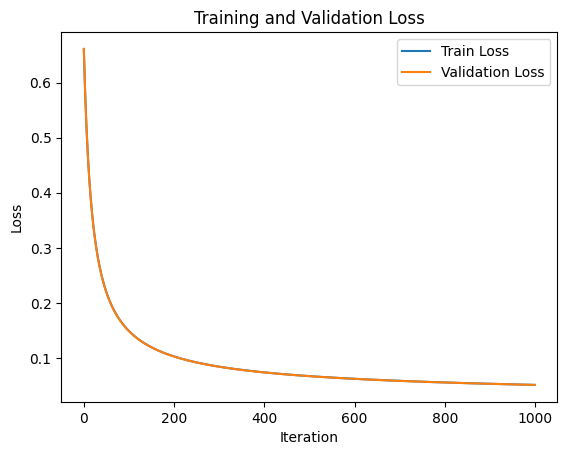

In [110]:
# Train the model
beta = np.zeros(X_train_s.shape[1])

beta, train_loss, val_loss = train_loop(
    X_train_s, y_train, X_val_s, y_val, beta,
    learning_rate=0.1, max_iter=1000)

plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [111]:
# Test
test_loss = cross_entropy_loss(y_test, sigmoid(X_test_s @ beta))
print(f"Test Loss: {test_loss:.4f}")

Test Loss: 0.0542


Confusion Matrix:
[[1625    5]
 [   3  367]]



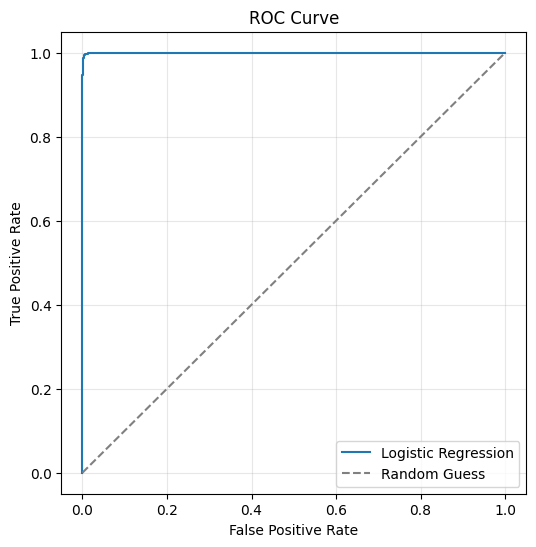

In [112]:
# Diagnose

# Confusion matrix
def confusion_matrix(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    return np.array([[TN, FP],
                     [FN, TP]])

# We need a threshold
# Classify as default if p >= 0.5
p_test = sigmoid(X_test_s @ beta)
y_pred = (p_test >= 0.5).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print()

# ROC AUC
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

p_test = sigmoid(X_test_s @ beta)

fpr, tpr, thresholds = roc_curve(y_test, p_test)
auc = roc_auc_score(y_test, p_test)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [113]:
# Function to calculate expected loss
def expected_loss_reg(loan_features, beta, mean, std, recovery_rate=0.1):
    """
    loan_features: feature vector for a single loan without intercept
    beta, mean, std: pre-trained model parameters and stats
    recovery_rate: percentage of loan amount that can be recovered in case of default
    Returns: Expected loss for the loan
    """
    # 1. Standardize and add intercept
    x = (loan_features - mean) / std
    x = np.concatenate([[1.0], x])

    # 2. Probability of default (PD)
    pd = sigmoid(x @ beta)

    # 3. Expected loss = PD × Loss given default x Exposure at default
    ead = loan_features[1]
    lgd = 1 - recovery_rate
    return pd * lgd * ead


# Test the function on a sample from the test set
sample = X_test[0]
el = expected_loss_reg(sample, beta, mean, std)
print(f"Sample loan amount: ${sample[1]:.2f}")
print(f"Expected Loss:      ${el:.2f}")

# Test the function on all test samples
total_expected_loss = [expected_loss_reg(x, beta, mean, std) for x in X_test]
print(f"Average Expected Loss on Test Set: ${np.mean(total_expected_loss):.2f}")

Sample loan amount: $3751.66
Expected Loss:      $1.24
Average Expected Loss on Test Set: $797.68


# 2. Decision Trees

In [114]:
# y: default
# X: all other variables except customer_id

X = loan_data.drop(columns=["default", "customer_id"]).to_numpy()
y = loan_data["default"].to_numpy()

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp)

# Step 1: Gini impurity
def gini(y):
    p = np.mean(y)
    return 2 * p * (1 - p)

# Step 2: Find partition
def best_split(X, y):
    best_gini_imp = float('inf')
    best_feature = None
    best_threshold = None
    n_samples, n_features = X.shape

    for feature in range(n_features):
        for threshold in np.unique(X[:, feature]):
            left_ind = X[:, feature] < threshold
            P_left  = y[left_ind]
            P_right = y[~left_ind]

            if len(P_left) == 0 or len(P_right) == 0:
                continue

            gini_imp = (len(P_left) * gini(P_left) +
                        len(P_right) * gini(P_right)) / n_samples

            if gini_imp < best_gini_imp:
                best_gini_imp = gini_imp
                best_feature = feature
                best_threshold = threshold

    return best_feature, best_threshold

# Step 3: Objective function
def objective_fct(y, y_pred, pen, size):
    R_n = np.mean(y != y_pred)
    obj = R_n + pen / len(y) * size
    return obj

# Step 4: Build the tree
def build_tree(X, y, depth=0, max_depth=10, min_samples=10):
    node_prob = np.mean(y)                   

    if depth >= max_depth or len(np.unique(y)) == 1 or len(y) < min_samples:
        return {
            "leaf": True, 
            "prob": node_prob
            }

    feature, threshold = best_split(X, y)
    if feature is None:
        return {
            "leaf": True, 
            "prob": node_prob
            }

    left_ind  = X[:, feature] < threshold     
    right_ind = ~left_ind                   

    X_left,  y_left  = X[left_ind],  y[left_ind]    
    X_right, y_right = X[right_ind], y[right_ind]   

    left_subtree  = build_tree(X_left,  y_left,  depth + 1, max_depth, min_samples)
    right_subtree = build_tree(X_right, y_right, depth + 1, max_depth, min_samples)

    return {
        "leaf": False,
        "feature": feature,
        "threshold": threshold,
        "prob": node_prob,
        "left":  left_subtree,
        "right": right_subtree
    }


# Step 5: Probability of default
def pred_one(node, x):
    if node["leaf"]:
        return node["prob"]
    
    if x[node["feature"]] < node["threshold"]:
        return pred_one(node["left"], x)
    else:
        return pred_one(node["right"], x)

def pred_multi(tree, X):
    return np.array([pred_one(tree, x) for x in X])

# Step 6: Prune the tree
def count_leaves(node):
    if node["leaf"]:
        return 1
    
    return count_leaves(node["left"]) + count_leaves(node["right"])

def get_nodes(tree):
    result = []
    def rec(node):
        if node["leaf"]:
            return
        if node["left"]["leaf"] and node["right"]["leaf"]:
            result.append(node)
        rec(node["left"])
        rec(node["right"])
    rec(tree)
    return result


def prune_tree(tree, X, y, pen):
    while True:
        y_pred = (pred_multi(tree, X) >= 0.5).astype(int)      # ← predict_many 改成 pred_multi
        current_obj = objective_fct(y, y_pred, pen, count_leaves(tree))

        best_obj, best_node = current_obj, None
        for node in get_nodes(tree):
            node["leaf"] = True
            y_pred = (pred_multi(tree, X) >= 0.5).astype(int)  # ← 这里也改
            obj = objective_fct(y, y_pred, pen, count_leaves(tree))
            node["leaf"] = False

            if obj < best_obj:
                best_obj, best_node = obj, node

        if best_node is None:
            break
        best_node["leaf"] = True

    return tree

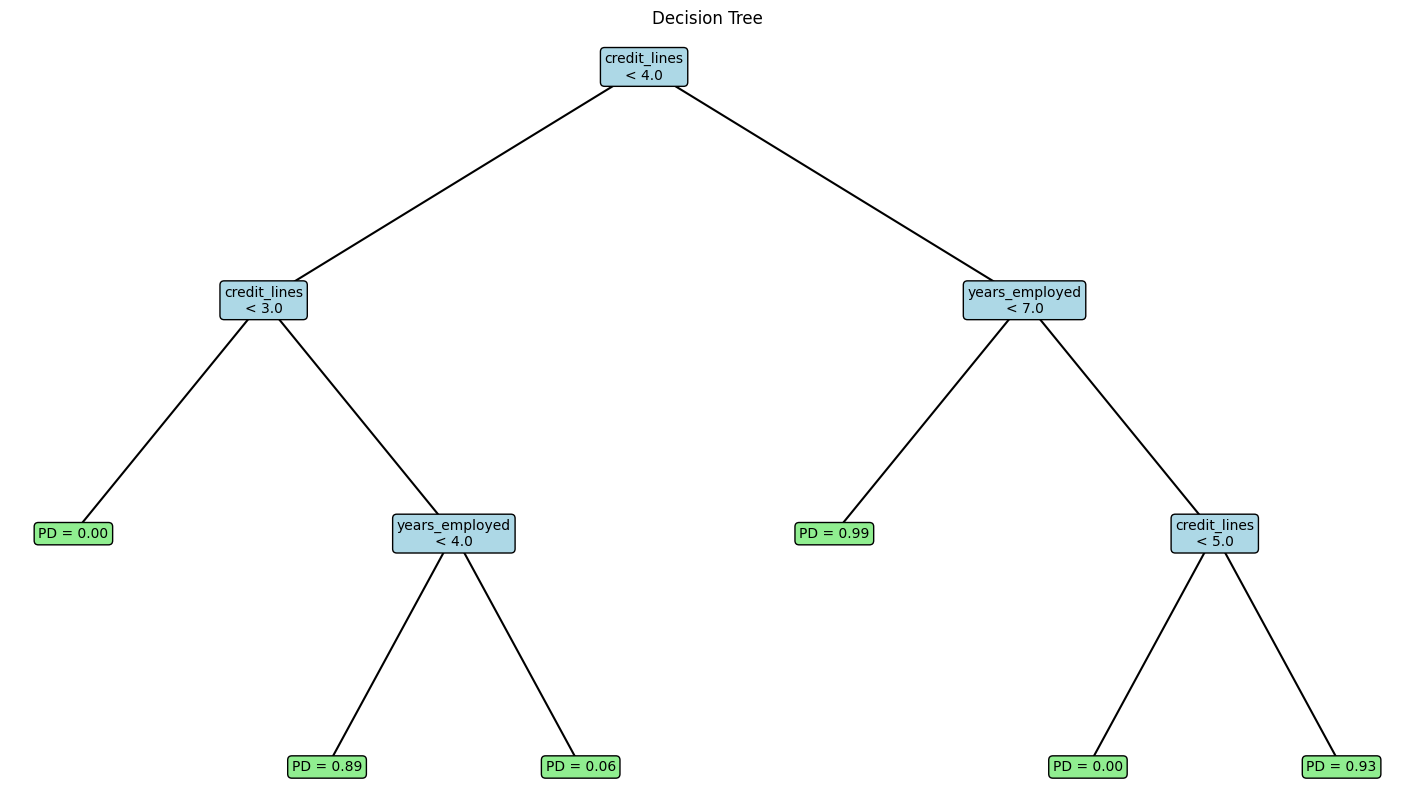

In [115]:
# Build the tree
tree = build_tree(X_train, y_train, max_depth=10, min_samples=10)
tree = prune_tree(tree, X_train, y_train, pen=10)

# Plot the tree
feature_names = ['credit_lines', 'loan_amt', 'total_debt',
                 'income', 'years_employed', 'fico_score']

def plot_tree(tree, figsize=(18, 10)):
    fig, ax = plt.subplots(figsize=figsize)
    positions = {}
    leaf_counter = [0]

    def assign_pos(node, depth):
        if node["leaf"]:
            x = leaf_counter[0]
            leaf_counter[0] += 1
        else:
            xl = assign_pos(node["left"],  depth + 1)
            xr = assign_pos(node["right"], depth + 1)
            x = (xl + xr) / 2
        positions[id(node)] = (x, -depth)     # y 用负深度，根在最上
        return x

    def draw(node):
        x, y = positions[id(node)]
        if node["leaf"]:
            ax.text(x, y, f"PD = {node['prob']:.2f}", ha='center', va='center',
                    bbox=dict(boxstyle='round', facecolor='lightgreen'))
        else:
            fname = feature_names[node["feature"]]
            ax.text(x, y, f"{fname}\n< {node['threshold']:.1f}", ha='center', va='center',
                    bbox=dict(boxstyle='round', facecolor='lightblue'))
            for child in (node["left"], node["right"]):
                cx, cy = positions[id(child)]
                ax.plot([x, cx], [y, cy], 'k-', zorder=0)
                draw(child)

    assign_pos(tree, 0)
    draw(tree)
    ax.axis('off')
    plt.title("Decision Tree")
    plt.show()

plot_tree(tree)

In [116]:
# Test
y_pred = (pred_multi(tree, X_test) >= 0.5).astype(int)

In [117]:
# Diagnose

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[1623    7]
 [   5  365]]


In [118]:
# Function to calculate expected loss
def expected_loss_tree(loan_features, tree, recovery_rate=0.1):
    """
    loan_features: feature vector for a single loan
    tree: trained decision tree
    recovery_rate: percentage of loan amount recovered in case of default
    Returns: Expected loss for the loan
    """
    # 1. Probability of default (PD) — walk the tree
    pd = pred_one(tree, loan_features)

    # 2. Expected loss = PD × Loss given default × Exposure at default
    ead = loan_features[1]
    lgd = 1 - recovery_rate
    return pd * lgd * ead


# Test the function on a sample from the test set
sample = X_test[0]
el = expected_loss_tree(sample, tree)
print(f"Sample loan amount: ${sample[1]:.2f}")
print(f"Expected Loss:      ${el:.2f}")

# Test the function on all test samples
total_expected_loss = [expected_loss_tree(x, tree) for x in X_test]
print(f"Average Expected Loss on Test Set: ${np.mean(total_expected_loss):.2f}")

Sample loan amount: $3751.66
Expected Loss:      $2.76
Average Expected Loss on Test Set: $748.71
